# 11 — Phase 1b Sensitivity: baseline damage rate (p02 vs p05 vs p10)

Goal:
Compare decision stability metrics across synthetic baseline damage rates:

- p02 = 2%
- p05 = 5%
- p10 = 10%

For each scenario and each k:
- Overlap + Jaccard between Top-k by `p_mean` and Top-k by `topk_prob`
- Spearman correlation between `p_mean` and `topk_prob`
- Borderline share: `0.2 < topk_prob < 0.8`

Outputs:
- `outputs/rtm/decision_stability/v1b/sensitivity_baseline_summary.csv`
- figures in `outputs/rtm/decision_stability/v1b/figures/`

Non-claim: synthetic outcome only; this is a mechanics validation.

In [1]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt

# --- Resolve repo root ---
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name.lower() == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

OUT_DIR = REPO_ROOT / "outputs" / "rtm" / "decision_stability" / "v1b"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

INF_DIR = REPO_ROOT / "outputs" / "rtm" / "inference"

SCENARIOS = {
    "p02": INF_DIR / "rtm_damage_v1b_p02_logistic_idata.nc",
    "p05": INF_DIR / "rtm_damage_v1b_logistic_idata.nc",  # your original p05 file name
    "p10": INF_DIR / "rtm_damage_v1b_p10_logistic_idata.nc",
}

print("Repo:", REPO_ROOT)
for s, p in SCENARIOS.items():
    print(s, "->", p)

Repo: C:\Users\C.Price\Habnetic\resilient-housing-bayes
p02 -> C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\inference\rtm_damage_v1b_p02_logistic_idata.nc
p05 -> C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\inference\rtm_damage_v1b_logistic_idata.nc
p10 -> C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\inference\rtm_damage_v1b_p10_logistic_idata.nc


In [2]:
missing = [s for s, p in SCENARIOS.items() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing idata files for: "
        + ", ".join(missing)
        + "\nCheck outputs/rtm/inference/*.nc filenames."
    )

idatas = {s: az.from_netcdf(p) for s, p in SCENARIOS.items()}

for s, idata in idatas.items():
    assert "p" in idata.posterior.data_vars, f"{s}: posterior missing 'p'. vars={list(idata.posterior.data_vars)}"
    print(s, "posterior p dims:", idata.posterior["p"].dims, "shape:", idata.posterior["p"].shape)

p02 posterior p dims: ('chain', 'draw', 'obs_id') shape: (2, 500, 5000)
p05 posterior p dims: ('chain', 'draw', 'obs_id') shape: (2, 500, 5000)
p10 posterior p dims: ('chain', 'draw', 'obs_id') shape: (2, 500, 5000)


In [3]:
def topk_membership_prob(p_samples: np.ndarray, k: int) -> np.ndarray:
    """
    p_samples: shape (S, N)  where S = total posterior draws (chains*draws)
    Returns topk_prob: shape (N,)
    """
    S, N = p_samples.shape
    if not (1 <= k <= N):
        raise ValueError(f"k must be in [1, N], got k={k}, N={N}")

    counts = np.zeros(N, dtype=np.int32)

    # Use argpartition for O(N) per draw instead of full sort O(N log N)
    for s in range(S):
        idx = np.argpartition(-p_samples[s], kth=k-1)[:k]
        counts[idx] += 1

    return counts / float(S)


def jaccard(a: np.ndarray, b: np.ndarray) -> float:
    a = np.asarray(a, dtype=np.int64)
    b = np.asarray(b, dtype=np.int64)
    A = set(a.tolist())
    B = set(b.tolist())
    inter = len(A.intersection(B))
    union = len(A.union(B))
    return inter / union if union else 0.0


def spearman_rho(x: np.ndarray, y: np.ndarray) -> float:
    # rank with average ties, then corr
    rx = pd.Series(x).rank(method="average").to_numpy()
    ry = pd.Series(y).rank(method="average").to_numpy()
    # Pearson correlation of ranks
    vx = rx - rx.mean()
    vy = ry - ry.mean()
    denom = np.sqrt((vx**2).sum() * (vy**2).sum())
    if denom == 0:
        return np.nan
    return float((vx * vy).sum() / denom)

In [4]:
k_values = [1000, 2500, 5000]  # must be <= N (N is your inference subsample size)
rows = []

for scen, idata in idatas.items():
    p = idata.posterior["p"]
    # stack chain+draw -> sample
    p_samples = p.stack(sample=("chain", "draw")).values  # shape (obs_id, S) OR (S, obs_id) depending on xarray ordering
    # xarray returns dims order = ('obs_id','sample') typically
    if p_samples.shape[0] == p.sizes.get("obs_id", p_samples.shape[0]):
        # shape (N, S) -> transpose to (S, N)
        p_samples = p_samples.T

    S, N = p_samples.shape
    print(f"{scen}: S={S}, N={N}")

    # posterior mean p per obs
    p_mean = p_samples.mean(axis=0)

    for k in k_values:
        if k > N:
            print(f"{scen}: skipping k={k} (k>N)")
            continue

        topk_prob = topk_membership_prob(p_samples, k=k)

        top_det = np.argsort(-p_mean)[:k]
        top_prob = np.argsort(-topk_prob)[:k]

        overlap = len(set(top_det.tolist()).intersection(set(top_prob.tolist()))) / float(k)
        jac = jaccard(top_det, top_prob)
        rho = spearman_rho(p_mean, topk_prob)

        borderline = float(((topk_prob > 0.2) & (topk_prob < 0.8)).mean())
        gt_02 = float((topk_prob > 0.2).mean())
        mean_topk = float(topk_prob.mean())
        entropy = -(topk_prob * np.log(topk_prob + 1e-12) + (1 - topk_prob) * np.log(1 - topk_prob + 1e-12))
        entropy_mean = float(entropy.mean())
        entropy_p95 = float(np.quantile(entropy, 0.95))

        rows.append({
            "scenario": scen,
            "k": k,
            "N": N,
            "k_over_N": k / float(N),
            "mean_topk_prob": mean_topk,          # sanity: should ~ k/N
            "overlap_ratio": overlap,             # |A∩B|/k
            "jaccard": jac,
            "spearman_rho": rho,
            "share_topk_prob_gt_0_2": gt_02,
            "share_topk_prob_between_0_2_0_8": borderline,
            "entropy_mean": entropy_mean,
            "entropy_p95": entropy_p95,
        })

summary = pd.DataFrame(rows).sort_values(["scenario", "k"]).reset_index(drop=True)
summary

p02: S=1000, N=5000
p05: S=1000, N=5000
p10: S=1000, N=5000


,scenario,k,N,k_over_N,mean_topk_prob,overlap_ratio,jaccard,spearman_rho,share_topk_prob_gt_0_2,share_topk_prob_between_0_2_0_8,entropy_mean,entropy_p95
0,p02,1000,5000,0.2,0.2,0.9970,0.994018,0.741303,0.2122,0.0244,2.524217e-02,1.615351e-01
1,p02,2500,5000,0.5,0.5,1.0000,1.000000,0.901495,0.5152,0.0302,3.205459e-02,2.641162e-01
2,p02,5000,5000,1.0,1.0,1.0000,1.000000,NaN,1.0000,0.0000,-1.000089e-12,-1.000089e-12
3,p05,1000,5000,0.2,0.2,1.0000,1.000000,0.736194,0.2078,0.0156,1.742836e-02,5.135415e-02
4,p05,2500,5000,0.5,0.5,0.9996,0.999200,0.898382,0.5122,0.0240,2.705029e-02,2.045072e-01
5,p05,5000,5000,1.0,1.0,1.0000,1.000000,NaN,1.0000,0.0000,-1.000089e-12,-1.000089e-12
6,p10,1000,5000,0.2,0.2,1.0000,1.000000,0.724149,0.2056,0.0114,1.224231e-02,-1.000089e-12
7,p10,2500,5000,0.5,0.5,1.0000,1.000000,0.892036,0.5108,0.0216,2.136981e-02,7.366331e-02
8,p10,5000,5000,1.0,1.0,1.0000,1.000000,NaN,1.0000,0.0000,-1.000089e-12,-1.000089e-12


## Sanity check

`mean(topk_prob)` should be approximately `k/N` (exact in expectation, close in finite samples).  
If that’s wildly off, you computed topk_prob on a different universe than the `k/N` you’re comparing to.

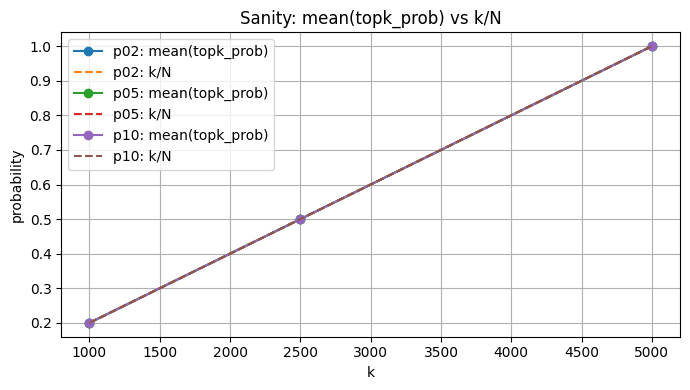

In [5]:
plt.figure(figsize=(7,4))
for scen in summary["scenario"].unique():
    sub = summary[summary["scenario"] == scen]
    plt.plot(sub["k"], sub["mean_topk_prob"], marker="o", label=f"{scen}: mean(topk_prob)")
    plt.plot(sub["k"], sub["k_over_N"], linestyle="--", label=f"{scen}: k/N")

plt.xlabel("k")
plt.ylabel("probability")
plt.title("Sanity: mean(topk_prob) vs k/N")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

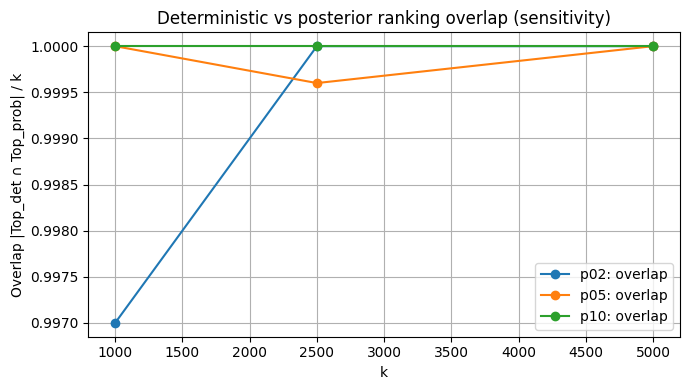

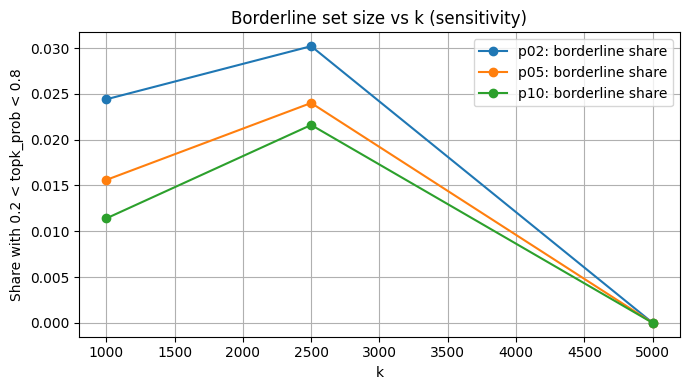

In [6]:
# Overlap/Jaccard across baselines
plt.figure(figsize=(7,4))
for scen in summary["scenario"].unique():
    sub = summary[summary["scenario"] == scen]
    plt.plot(sub["k"], sub["overlap_ratio"], marker="o", label=f"{scen}: overlap")

plt.xlabel("k")
plt.ylabel("Overlap |Top_det ∩ Top_prob| / k")
plt.title("Deterministic vs posterior ranking overlap (sensitivity)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,4))
for scen in summary["scenario"].unique():
    sub = summary[summary["scenario"] == scen]
    plt.plot(sub["k"], sub["share_topk_prob_between_0_2_0_8"], marker="o", label=f"{scen}: borderline share")

plt.xlabel("k")
plt.ylabel("Share with 0.2 < topk_prob < 0.8")
plt.title("Borderline set size vs k (sensitivity)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
out_csv = OUT_DIR / "sensitivity_baseline_summary.csv"
summary.to_csv(out_csv, index=False)
print("Saved:", out_csv)

# Also save a quick markdown-ish table snapshot for your docs
out_md = OUT_DIR / "sensitivity_baseline_summary.md"
with open(out_md, "w", encoding="utf-8") as f:
    f.write(summary.to_markdown(index=False))
print("Saved:", out_md)

Saved: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1b\sensitivity_baseline_summary.csv
Saved: C:\Users\C.Price\Habnetic\resilient-housing-bayes\outputs\rtm\decision_stability\v1b\sensitivity_baseline_summary.md


## Interpretation (what Step B demonstrates)

- Changing the baseline damage rate changes the decision stability profile.
- With higher baseline (p10), posterior probabilities tend to be less sparse and rankings can become more stable/less stable depending on signal-to-noise.
- The key evidence is the movement of:
  - overlap curves (Top-k by mean vs Top-k by posterior membership)
  - borderline share curves (0.2–0.8 band)

This is the minimal stress test showing: **decision stability depends on base rate**, even with fixed exposure/hazard structure.

In [8]:
print(
    summary.groupby("scenario")[
        ["overlap_ratio", "share_topk_prob_between_0_2_0_8"]
    ].mean()
)

          overlap_ratio  share_topk_prob_between_0_2_0_8
scenario                                                
p02            0.999000                           0.0182
p05            0.999867                           0.0132
p10            1.000000                           0.0110


In [9]:
for scen in ["p02","p05","p10"]:
    print(scen)
    print(az.summary(idatas[scen], var_names=["alpha"]))

p02
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha -3.978  0.119  -4.191   -3.742      0.005    0.004     575.0     578.0   

       r_hat  
alpha   1.01  
p05
        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha -3.019  0.082  -3.172   -2.872      0.004    0.003     523.0     575.0   

       r_hat  
alpha    1.0  
p10
       mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
alpha -2.15  0.054  -2.245   -2.041      0.002    0.002     578.0     515.0   

       r_hat  
alpha    1.0  
